# Marketing Analytics — Web Traffic Forecast

---

## Objective

This project uses time series forecasting to model website traffic patterns and project future daily click volume. The goal is to move beyond simply observing historical traffic and instead build a data-driven forward view — one that accounts for seasonal patterns, weekly rhythms, and underlying trend direction. Understanding where traffic is likely to go, rather than only where it has been, is useful for proactive campaign planning and for identifying potential performance dips before they appear in live dashboards. The model is built using Facebook Prophet, which is well-suited to daily business time series data and handles seasonality with minimal manual configuration.

## Data

The primary dataset is a daily web traffic export — Clicks.csv — containing a date column and a corresponding traffic volume for each day. A second file, art_daily_small_noise.csv from the Numenta Anomaly Benchmark, is used as a synthetic reference series to demonstrate model behavior on a clean signal. Both files follow a simple two-column structure that maps directly to Prophet's required ds (date) and y (value) format. Minimal preprocessing is needed: the date column is parsed and the data is sorted chronologically before fitting.

In [1]:
!pip install prophet
!wget https://raw.githubusercontent.com/numenta/NAB/master/data/artificialNoAnomaly/art_daily_small_noise.csv

--2026-07-27 22:40:42--  https://raw.githubusercontent.com/numenta/NAB/master/data/artificialNoAnomaly/art_daily_small_noise.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 

185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 140187 (137K) [text/plain]
Saving to: ‘art_daily_small_noise.csv.1’

          art_daily   0%[                    ]       0  --.-KB/s               

art_daily_small_noi 100%[===================>] 136.90K  --.-KB/s    in 0.03s   

2026-07-27 22:40:42 (3.86 MB/s) - ‘art_daily_small_noise.csv.1’ saved [140187/140187]



In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns
import chardet as cd
import numpy as np
import matplotlib.pyplot as plt

#Files Upload & Data Prep

In [3]:
#Load the data
df = pd.read_csv("marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Initech,Radio,45-54,62,Facebook,0.0310,63.11,21.77,San Diego,German,910,16145,0.04,Youth,2021-01-01
1,2,Umbrella,Influencer,35-44,23,Google Ads,0.1598,158.41,94.40,Chicago,Spanish,503,8809,4.48,Senior,2021-01-01
2,3,Globex,TV,18-24,33,TV,0.0320,280.79,0.00,Los Angeles,French,4789,67917,8.37,Youth,2021-01-01
3,4,Acme Corp,Influencer,45-54,9,Twitter,0.1725,65.60,41.26,Chicago,Spanish,2374,12029,0.35,Youth,2021-01-01
4,5,Umbrella,Influencer,45-54,35,YouTube,0.0729,77.41,71.45,San Diego,French,2327,21084,6.94,Middle Aged,2021-01-01


#Drop Columns

In [4]:
# Extract date and clicks for time series forecasting
traffic = df[['Date', 'Clicks']].copy()
traffic['Date'] = pd.to_datetime(traffic['Date'])
traffic = traffic.groupby('Date')['Clicks'].sum().reset_index()
traffic.head()

,Date,Clicks
0,2021-01-01,55370
1,2021-01-02,73556
2,2021-01-03,48577
3,2021-01-04,68712
4,2021-01-05,66137


In [5]:
traffic.tail()

,Date,Clicks
412,2022-02-17,63821
413,2022-02-18,59571
414,2022-02-19,65124
415,2022-02-20,65823
416,2022-02-21,29430


In [6]:
traffic.describe()

,Date,Clicks
count,417,417.000000
mean,2021-07-28 00:00:00,60807.436451
min,2021-01-01 00:00:00,29430.000000
25%,2021-04-15 00:00:00,56100.000000
50%,2021-07-28 00:00:00,61227.000000
75%,2021-11-09 00:00:00,65575.000000
max,2022-02-21 00:00:00,76942.000000
std,NaN,6897.425622


In [7]:
df.shape

(10000, 16)

#Check for missing data

In [8]:
traffic.isnull().sum()

Date      0
Clicks    0
dtype: int64

#Describe the data

In [9]:
traffic.describe()

,Date,Clicks
count,417,417.000000
mean,2021-07-28 00:00:00,60807.436451
min,2021-01-01 00:00:00,29430.000000
25%,2021-04-15 00:00:00,56100.000000
50%,2021-07-28 00:00:00,61227.000000
75%,2021-11-09 00:00:00,65575.000000
max,2022-02-21 00:00:00,76942.000000
std,NaN,6897.425622


In [10]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    417 non-null    datetime64[us]
 1   Clicks  417 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 6.6 KB


In [11]:
traffic.dtypes

Date      datetime64[us]
Clicks             int64
dtype: object

#Converting columns into FB Prohpet names

In [12]:
traffic.columns = ['ds', 'y']

In [13]:
traffic.head()

,ds,y
0,2021-01-01,55370
1,2021-01-02,73556
2,2021-01-03,48577
3,2021-01-04,68712
4,2021-01-05,66137


#Creating Forecast

###Forecasting by default has period = 365, which a forecast of one calender year. We can adjust this by either a longer or shorter period.

In [14]:
m = Prophet()
m.fit(traffic)

22:40:44 - cmdstanpy - INFO - Chain [1] start processing


22:40:44 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
777,2023-02-17
778,2023-02-18
779,2023-02-19
780,2023-02-20
781,2023-02-21


In [16]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
777,2023-02-17,59409.954481,50533.209949,68249.001374
778,2023-02-18,59144.716451,49666.329725,67553.021850
779,2023-02-19,58836.247781,50254.427231,67814.004595
780,2023-02-20,58923.673788,51200.326591,68288.904874
781,2023-02-21,58992.016381,50318.307582,67227.193150


For our data predictions, we can see our ranges(ds). The data shows the upper(yhat_upper) and lower(yhat_lower) bounds of our prediction.

#Forecast Visualization

Text(0, 0.5, 'Traffic')

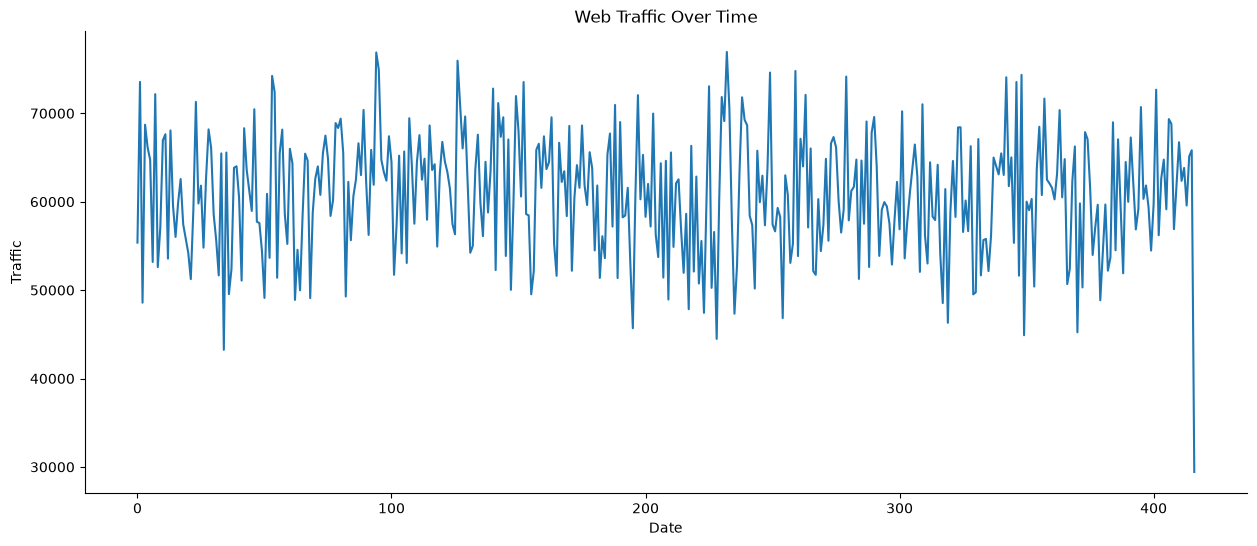

In [17]:
from matplotlib import pyplot as plt
traffic['y'].plot(kind='line', figsize=(15, 6), title='y')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.title('Web Traffic Over Time')
plt.xlabel('Date')
plt.ylabel('Traffic')

Text(64.72222222222221, 0.5, 'Traffic')

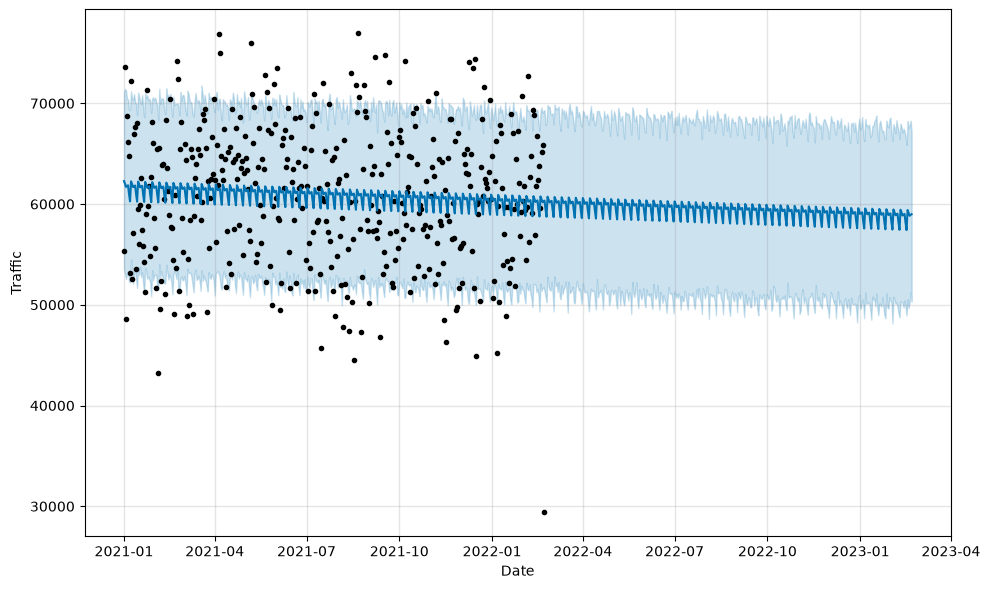

In [18]:
fig1 = m.plot(forecast)

plt.xlabel('Date')
plt.ylabel('Traffic')

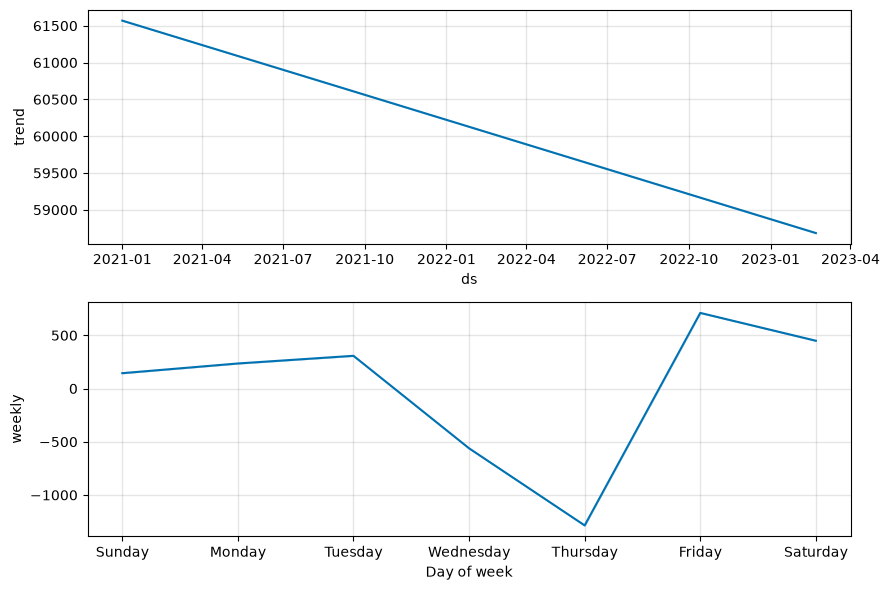

In [19]:
fig2 = m.plot_components(forecast)

In [20]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

Based on the analysis of our current marketing campaign, it's evident that our efforts have maintained a steady trajectory thus far, yielding consistent results. However, a closer examination reveals potential challenges that could lead to a decline in the future.


Campaign metrics such as click-through rates (CTR) and conversion rates have shown stable performance. This indicates that our strategies have resonated with our target audience and generated satisfactory engagement.


Recommendations:

* Diversify Targeting:
    * Expand our audience segments to include demographics or regions that show potential for growth. Conduct thorough market research to identify untapped opportunities.

* Innovate Campaigns:
    * Experiment with new marketing channels or tactics that align with emerging trends. This could include leveraging social media platforms more effectively or investing in content marketing to improve organic reach.

* Customer Engagement:
    * Increase focus on personalized marketing strategies that cater to individual customer preferences. Utilize data analytics to segment our audience more precisely and deliver targeted campaigns that drive engagement and loyalty.


By implementing these recommendations into our startegy, we can mitigate the potential decline in our marketing campaign's effectiveness and position ourselves for sustained growth in the competitive landscape ahead.

